# Aggressive-downsampling stress test — grid 4→8×

**Question.** Take the *same* grid-4×-trained base and DDPO models (4096-pt inputs, ~6% sampling) and
hand them progressively sparser inputs — grid 5/6/7/8× = 2704 / 1849 / 1369 / 1024 points. How do they
degrade, does the physics guidance still help, and does the K=3 multi-phase sampler buy anything?
`grid-4×` is the training density (green dotted line); everything to its right is extrapolation to inputs
the models never saw.

Full matrix per grid factor, per regime: **{base, DDPO} × {K=1, K=3} × {unguided, x0-guided λ=3}**.
Metrics: hi-k **retention** (recon high-k energy / GT), energy **placement** (corr of local high-k energy
with GT — *where* the energy goes), PDE **residual** (mean |NS-residual|), **MSE**, effective resolution k*.

In [1]:
import os, sys, pickle
import numpy as np
import matplotlib.pyplot as plt
import jax, jax.numpy as jnp

# Resolve to repo root regardless of launch dir (nbconvert runs the kernel in the notebook's dir)
for _cand in ('.', '..', '../..', '/home/rhautier/ddpm-jax'):
    if os.path.isdir(os.path.join(_cand, 'flow-data')) and os.path.isdir(os.path.join(_cand, 'monitoring')):
        os.chdir(_cand); break
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('src/ddpo_ft'))
print('cwd:', os.getcwd())

from diag_guided_residual import make_guided_sampler
from train_claude import build_base_ddpm
from viz_energy import local_hik_energy
from src.physics_guidance import make_dx_func, make_ns_residual
from src.rewards import make_spectrum_fn
from src.sequence_inference import build_triplets, grid_downsample_degrade, load_sequence

MEAN, STD, N, HIK0 = 0.0, 4.7988, 256, 32
S_MULTI, T_START, LAM = [150, 100, 50], 100, 3.0
GRIDS = [4, 5, 6, 7, 8]
PTS = {4: 4096, 5: 2704, 6: 1849, 7: 1369, 8: 1024}
GT_RESID = {1000: 1.06, 2000: 3.01}
LOGDIR = 'monitoring/ab_pdelocal'
print('jax devices:', jax.devices())

cwd: /home/rhautier/ddpm-jax


jax devices: [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0), TpuDevice(id=1, process_index=0, coords=(1,0,0), core_on_chip=0), TpuDevice(id=2, process_index=0, coords=(0,1,0), core_on_chip=0), TpuDevice(id=3, process_index=0, coords=(1,1,0), core_on_chip=0)]


## 1. Degradation curves (both regimes, from the full sweep logs)

Parsed straight from the `eval_guided_full` sweep logs. Four panels per regime: MSE, placement,
retention, residual — each vs grid factor (sparser to the right).

In [2]:
def parse_stress_logs():
    rows = {}
    for re_val in (1000, 2000):
        for gf in GRIDS:
            for K, suff in ((1, ''), (3, '_k3')):
                path = f'{LOGDIR}/stress_re{re_val}_g{gf}{suff}.log'
                if not os.path.exists(path):
                    continue
                for line in open(path):
                    p = line.split()
                    if len(p) >= 7 and p[0] in ('base', 'DDPO') and p[1] in ('off', 'lam3'):
                        rows[(re_val, K, gf, p[0], p[1])] = dict(
                            ret=float(p[2]), resid=float(p[3]), mse=float(p[4]),
                            place=float(p[5]), kstar=int(p[6]))
    return rows

DATA = parse_stress_logs()
def get(re_val, K, model, guide, key):
    return np.array([DATA.get((re_val, K, gf, model, guide), {}).get(key, np.nan) for gf in GRIDS])
print(f'parsed {len(DATA)} rows (expect 80: 2 re x 2 K x 5 grid x 2 model x 2 guide)')

parsed 80 rows (expect 80: 2 re x 2 K x 5 grid x 2 model x 2 guide)


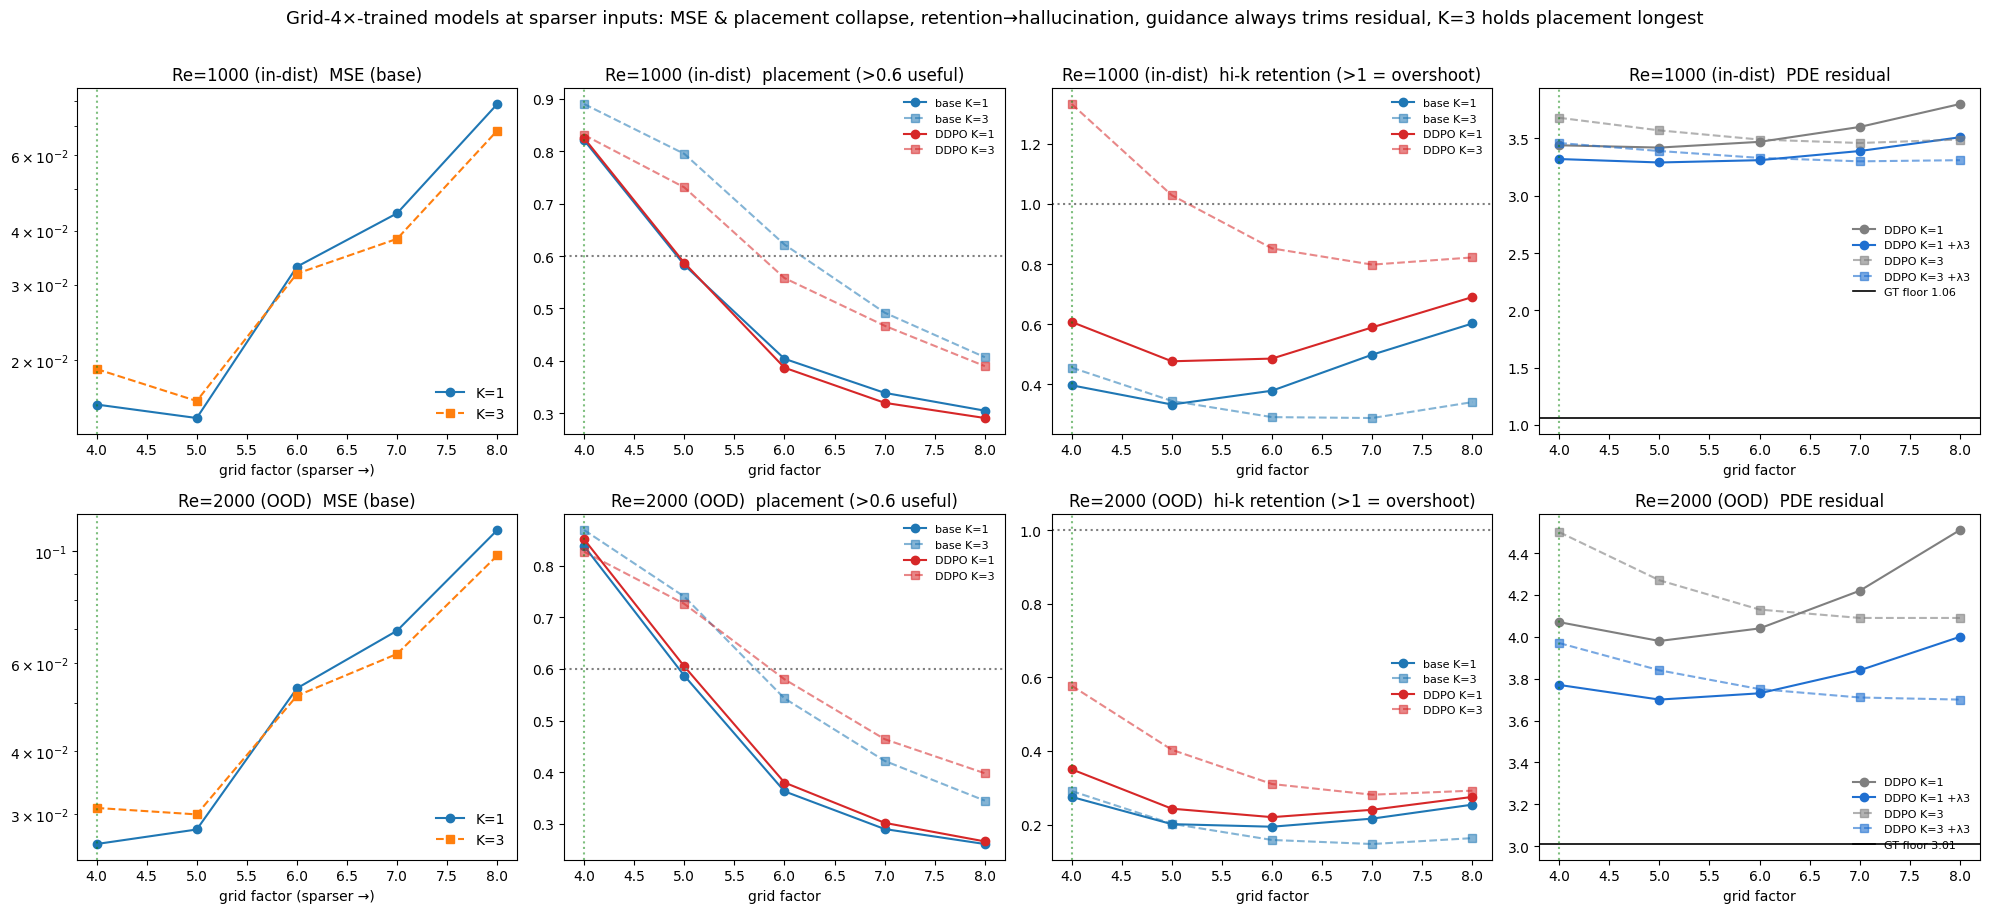

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ri, re_val in enumerate((1000, 2000)):
    tag = 'in-dist' if re_val == 1000 else 'OOD'
    ax = axes[ri, 0]
    ax.plot(GRIDS, get(re_val, 1, 'base', 'off', 'mse'), 'o-', color='#1f77b4', label='K=1')
    ax.plot(GRIDS, get(re_val, 3, 'base', 'off', 'mse'), 's--', color='#ff7f0e', label='K=3')
    ax.set_yscale('log'); ax.axvline(4, color='green', ls=':', alpha=.5)
    ax.set_title(f'Re={re_val} ({tag})  MSE (base)'); ax.set_xlabel('grid factor (sparser →)'); ax.legend(frameon=False)
    ax = axes[ri, 1]
    for m, c in (('base', '#1f77b4'), ('DDPO', '#d62728')):
        ax.plot(GRIDS, get(re_val, 1, m, 'off', 'place'), 'o-', color=c, label=f'{m} K=1')
        ax.plot(GRIDS, get(re_val, 3, m, 'off', 'place'), 's--', color=c, alpha=.55, label=f'{m} K=3')
    ax.axhline(0.6, color='gray', ls=':'); ax.axvline(4, color='green', ls=':', alpha=.5)
    ax.set_title(f'Re={re_val} ({tag})  placement (>0.6 useful)'); ax.set_xlabel('grid factor'); ax.legend(frameon=False, fontsize=8)
    ax = axes[ri, 2]
    for m, c in (('base', '#1f77b4'), ('DDPO', '#d62728')):
        ax.plot(GRIDS, get(re_val, 1, m, 'off', 'ret'), 'o-', color=c, label=f'{m} K=1')
        ax.plot(GRIDS, get(re_val, 3, m, 'off', 'ret'), 's--', color=c, alpha=.55, label=f'{m} K=3')
    ax.axhline(1.0, color='k', ls=':', alpha=.5); ax.axvline(4, color='green', ls=':', alpha=.5)
    ax.set_title(f'Re={re_val} ({tag})  hi-k retention (>1 = overshoot)'); ax.set_xlabel('grid factor'); ax.legend(frameon=False, fontsize=8)
    ax = axes[ri, 3]
    ax.plot(GRIDS, get(re_val, 1, 'DDPO', 'off', 'resid'), 'o-', color='#7f7f7f', label='DDPO K=1')
    ax.plot(GRIDS, get(re_val, 1, 'DDPO', 'lam3', 'resid'), 'o-', color='#1f6fd0', label='DDPO K=1 +λ3')
    ax.plot(GRIDS, get(re_val, 3, 'DDPO', 'off', 'resid'), 's--', color='#7f7f7f', alpha=.6, label='DDPO K=3')
    ax.plot(GRIDS, get(re_val, 3, 'DDPO', 'lam3', 'resid'), 's--', color='#1f6fd0', alpha=.6, label='DDPO K=3 +λ3')
    ax.axhline(GT_RESID[re_val], color='k', lw=1.2, label=f'GT floor {GT_RESID[re_val]}')
    ax.axvline(4, color='green', ls=':', alpha=.5)
    ax.set_title(f'Re={re_val} ({tag})  PDE residual'); ax.set_xlabel('grid factor'); ax.legend(frameon=False, fontsize=8)
fig.suptitle('Grid-4×-trained models at sparser inputs: MSE & placement collapse, retention→hallucination, '
             'guidance always trims residual, K=3 holds placement longest', y=1.01, fontsize=13)
plt.tight_layout(); plt.savefig(f'{LOGDIR}/grid_stress_degradation.png', dpi=115, bbox_inches='tight'); plt.show()

## 2. Reconstructions across sparsity (Re=1000, in-dist)

One test frame (seq 36), reconstructed at each grid factor. Columns: GT, then base/DDPO under K=1 and K=3
(unguided). Watch the fine vortex filaments: **K=3 keeps structure where K=1 washes out** as the input
sparsens. Reconstructions are cached to `.npz` so re-runs are instant.

In [4]:
RE = 1000
R1 = 'monitoring/ddpo_re1000_grid4x_ckpts/ddpo_re1000_iter0199.pkl'
GT_PATH = 'flow-data/kf_2d_re1000_256_40seed.npy'
ddpm, base_params, _ = build_base_ddpm()
ddpo = pickle.load(open(R1, 'rb'))['params']
ab = ddpm.alpha_bar
dx = make_dx_func(n=N, re=float(RE), std=STD, mean=MEAN)
resid = jax.jit(make_ns_residual(n=N, re=float(RE)))
spec_fn = make_spectrum_fn(N)
levels = sorted({T_START, *S_MULTI})
sU = {t: make_guided_sampler(ddpm.unet, ab, ddpm.beta_schedule, t, dx, 0.0) for t in levels}
sG = {t: make_guided_sampler(ddpm.unet, ab, ddpm.beta_schedule, t, dx, LAM) for t in levels}
PARAMS = {'base': base_params, 'DDPO': ddpo}

def noise_to(x, t, kk):
    return float(jnp.sqrt(ab[t])) * x + float(jnp.sqrt(1 - ab[t])) * jax.random.normal(kk, x.shape)

def reconstruct(xin, model, K, guided=False, seed=1):
    sdict = sG if guided else sU; params = PARAMS[model]
    key = jax.random.PRNGKey(seed)
    if K == 3:
        xc = jnp.asarray(xin)
        for j, Sj in enumerate(S_MULTI):
            xc = sdict[Sj](params, noise_to(xc, Sj, jax.random.fold_in(key, 10 + j)), jax.random.fold_in(key, 20 + j))
        return np.asarray(xc)
    xn = noise_to(jnp.asarray(xin), T_START, jax.random.fold_in(key, 10))
    return np.asarray(sdict[T_START](params, xn, jax.random.fold_in(key, 20)))

Type of the model constructed with no cond <class 'src.models.model.Unet'>
base DDPM: Unet | epoch 299 | T=1000


In [5]:
SEQ = 36
seq = load_sequence(GT_PATH, SEQ)
gt_trip = build_triplets(seq, MEAN, STD)
FIDX = len(gt_trip) * 3 // 4
xgt = gt_trip[FIDX:FIDX + 1]
INP = {gf: build_triplets(grid_downsample_degrade(seq, gf), MEAN, STD)[FIDX:FIDX + 1] for gf in GRIDS}

CACHE = f'{LOGDIR}/grid_stress_recons_re{RE}_seq{SEQ}.npz'
if os.path.exists(CACHE):
    Z = dict(np.load(CACHE)); print('loaded cached recons from', CACHE)
else:
    Z = {}
    for gf in GRIDS:
        for K in (1, 3):
            for model in ('base', 'DDPO'):
                Z[f'{gf}_K{K}_{model}_u'] = reconstruct(INP[gf], model, K, guided=False)
        Z[f'{gf}_K1_DDPO_g'] = reconstruct(INP[gf], 'DDPO', 1, guided=True)  # for the residual panel
        print(f'grid-{gf}× done')
    np.savez_compressed(CACHE, **Z); print('cached', CACHE)

grid-4× done


grid-5× done


grid-6× done


grid-7× done


grid-8× done


cached monitoring/ab_pdelocal/grid_stress_recons_re1000_seq36.npz


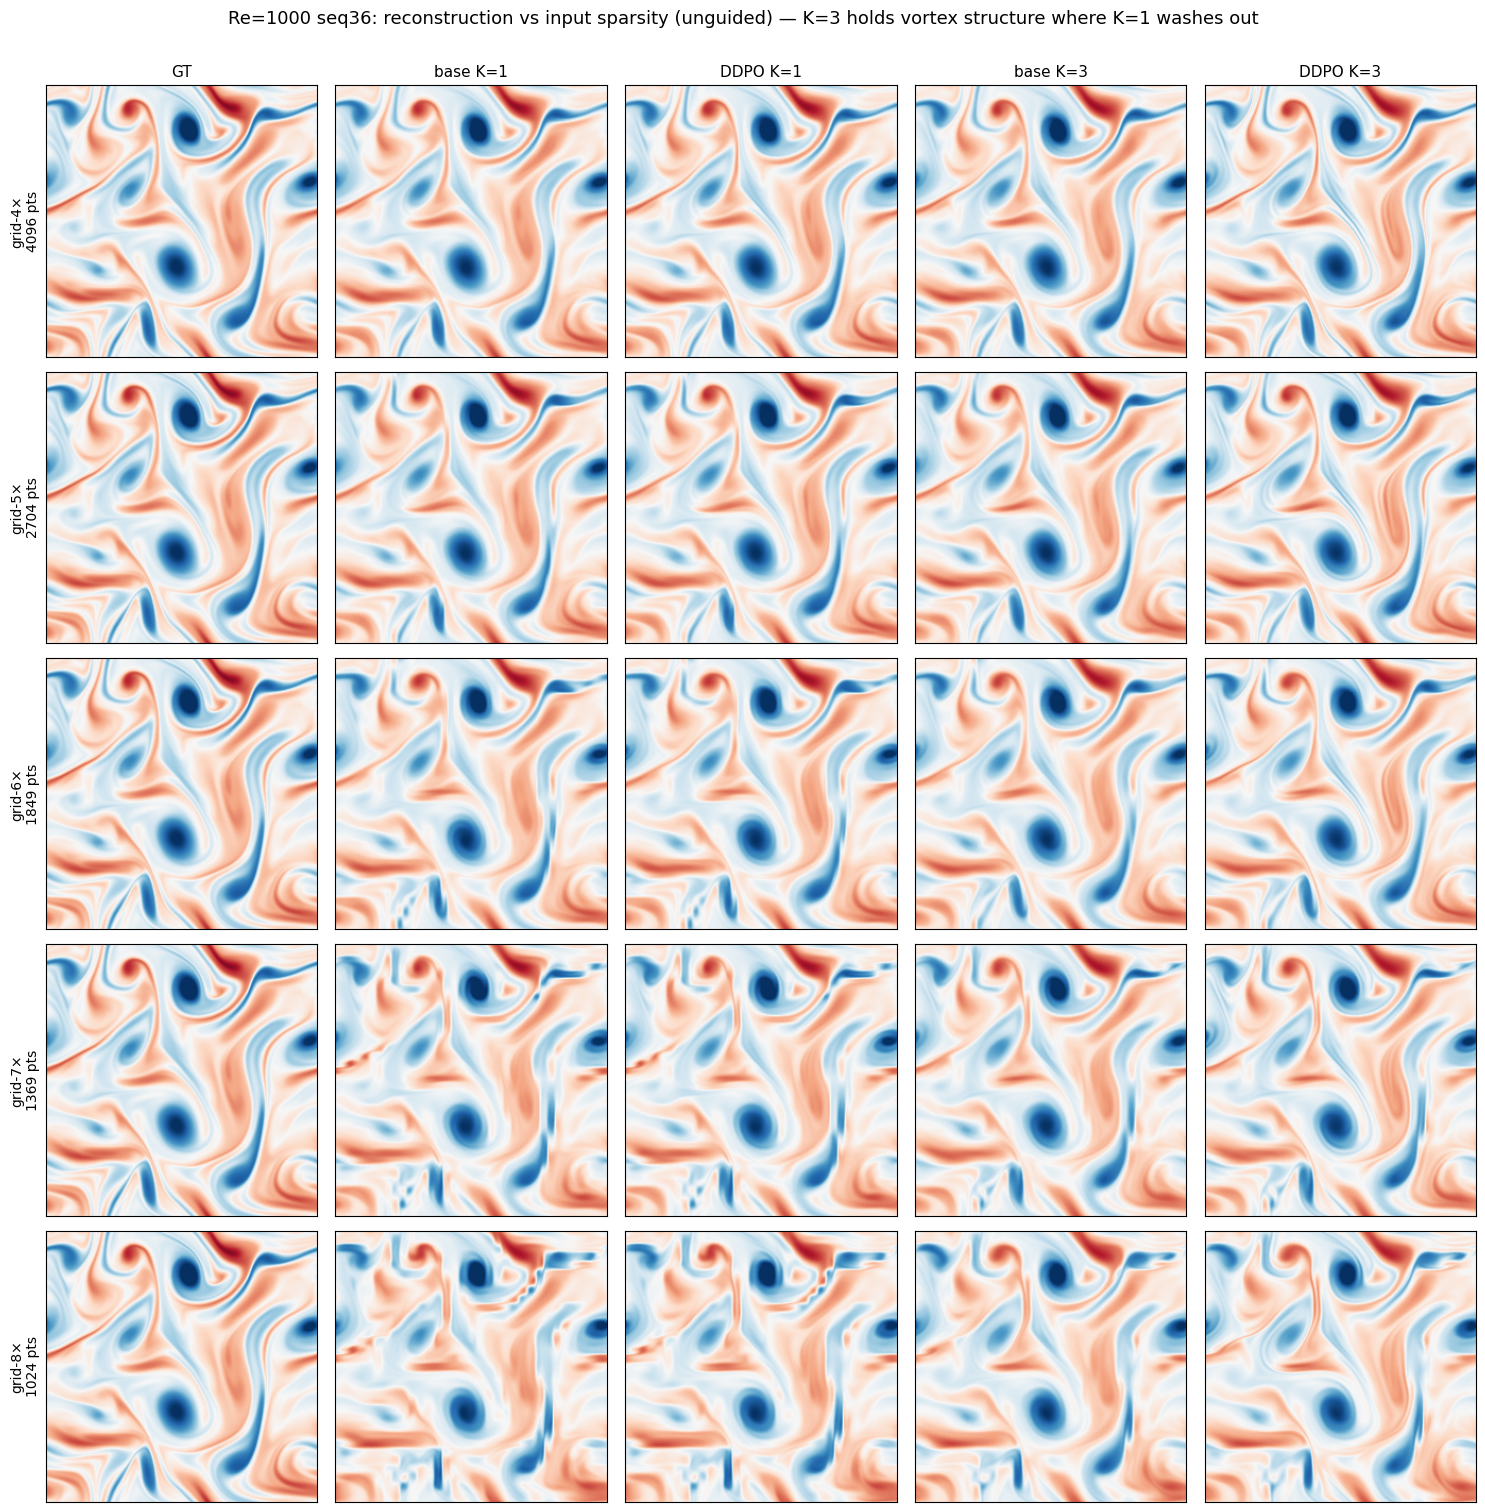

In [6]:
def vort(trip): return trip[0, ..., 1] * STD   # middle-frame vorticity
vv = float(np.percentile(np.abs(vort(xgt)), 99.5))
cols = [('GT', None), ('base K=1', (1, 'base')), ('DDPO K=1', (1, 'DDPO')),
        ('base K=3', (3, 'base')), ('DDPO K=3', (3, 'DDPO'))]
fig, axes = plt.subplots(len(GRIDS), 5, figsize=(15, 3 * len(GRIDS)))
for r, gf in enumerate(GRIDS):
    for c, (name, spec) in enumerate(cols):
        ax = axes[r, c]
        d = vort(xgt) if spec is None else Z[f'{gf}_K{spec[0]}_{spec[1]}_u'][0, ..., 1] * STD
        ax.imshow(d, cmap='RdBu_r', vmin=-vv, vmax=vv); ax.set_xticks([]); ax.set_yticks([])
        if r == 0: ax.set_title(name, fontsize=11)
    axes[r, 0].set_ylabel(f'grid-{gf}×\n{PTS[gf]} pts', fontsize=10)
fig.suptitle(f'Re={RE} seq{SEQ}: reconstruction vs input sparsity (unguided) — K=3 holds vortex structure '
             f'where K=1 washes out', y=1.005, fontsize=13)
plt.tight_layout(); plt.savefig(f'{LOGDIR}/grid_stress_recon_montage.png', dpi=115, bbox_inches='tight'); plt.show()

## 3. Enstrophy spectra vs sparsity

Per grid factor: GT vs base/DDPO under K=1/K=3. Green band = the high-k reward region. DDPO K=3 **overshoots**
the GT band at high density (grid-4/5×); all curves lose high-k content as the input sparsens.

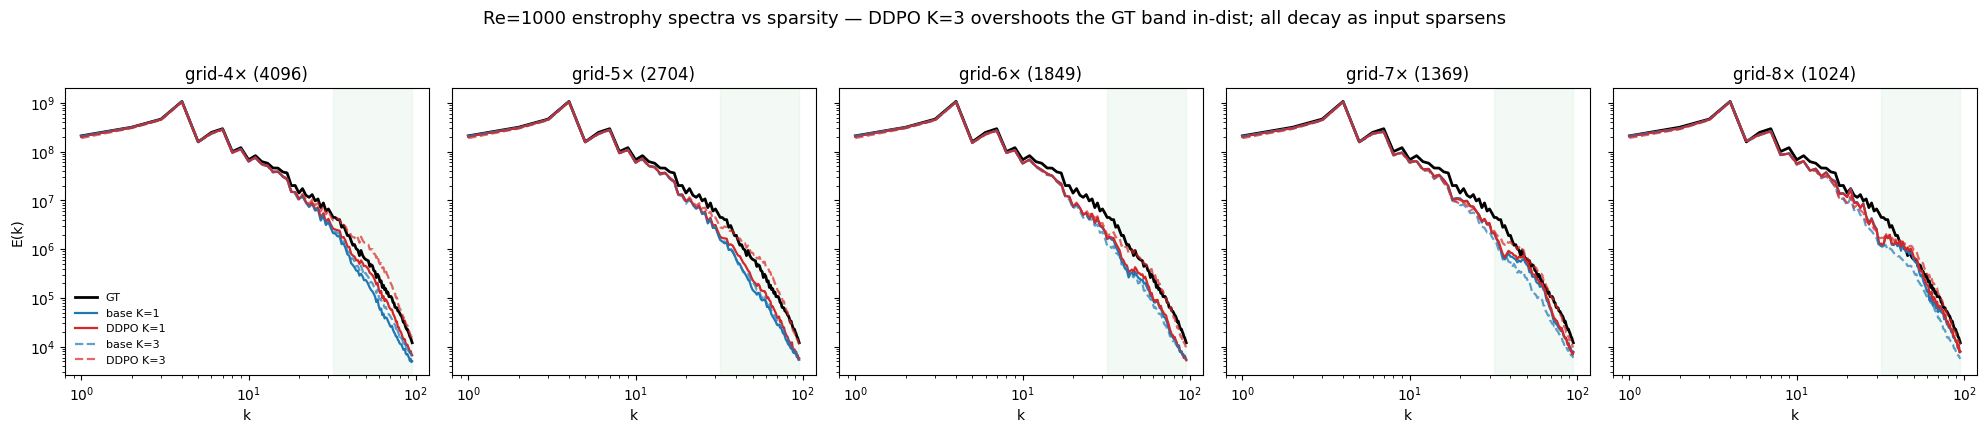

In [7]:
kx = np.arange(1, 96)
E_gt = np.asarray(spec_fn(jnp.asarray(xgt))).mean(0)
fig, axes = plt.subplots(1, len(GRIDS), figsize=(4 * len(GRIDS), 4.2), sharey=True)
for c, gf in enumerate(GRIDS):
    ax = axes[c]; ax.plot(kx, E_gt[1:96], 'k-', lw=2, label='GT')
    for K, ls, al in ((1, '-', 1.0), (3, '--', 0.7)):
        for m, col in (('base', '#1f77b4'), ('DDPO', '#d62728')):
            E = np.asarray(spec_fn(jnp.asarray(Z[f'{gf}_K{K}_{m}_u']))).mean(0)
            ax.plot(kx, E[1:96], ls=ls, color=col, alpha=al, lw=1.6, label=f'{m} K={K}')
    ax.axvspan(HIK0, 95, color='#3ca951', alpha=.06); ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(f'grid-{gf}× ({PTS[gf]})'); ax.set_xlabel('k')
    if c == 0: ax.set_ylabel('E(k)'); ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Re={RE} enstrophy spectra vs sparsity — DDPO K=3 overshoots the GT band in-dist; '
             f'all decay as input sparsens', y=1.02, fontsize=13)
plt.tight_layout(); plt.savefig(f'{LOGDIR}/grid_stress_spectra.png', dpi=115, bbox_inches='tight'); plt.show()

## 4. Residual fields + guidance effect

|NS-residual| for GT vs the DDPO K=1 reconstruction, unguided and with λ=3 guidance, at grid 4/6/8×.
GT's residual is dark/clean on a few coherent filaments; the recon's is speckled everywhere. The Δ panel
(blue = reduced) shows λ=3 guidance trimming residual roughly uniformly — the density-independent win.

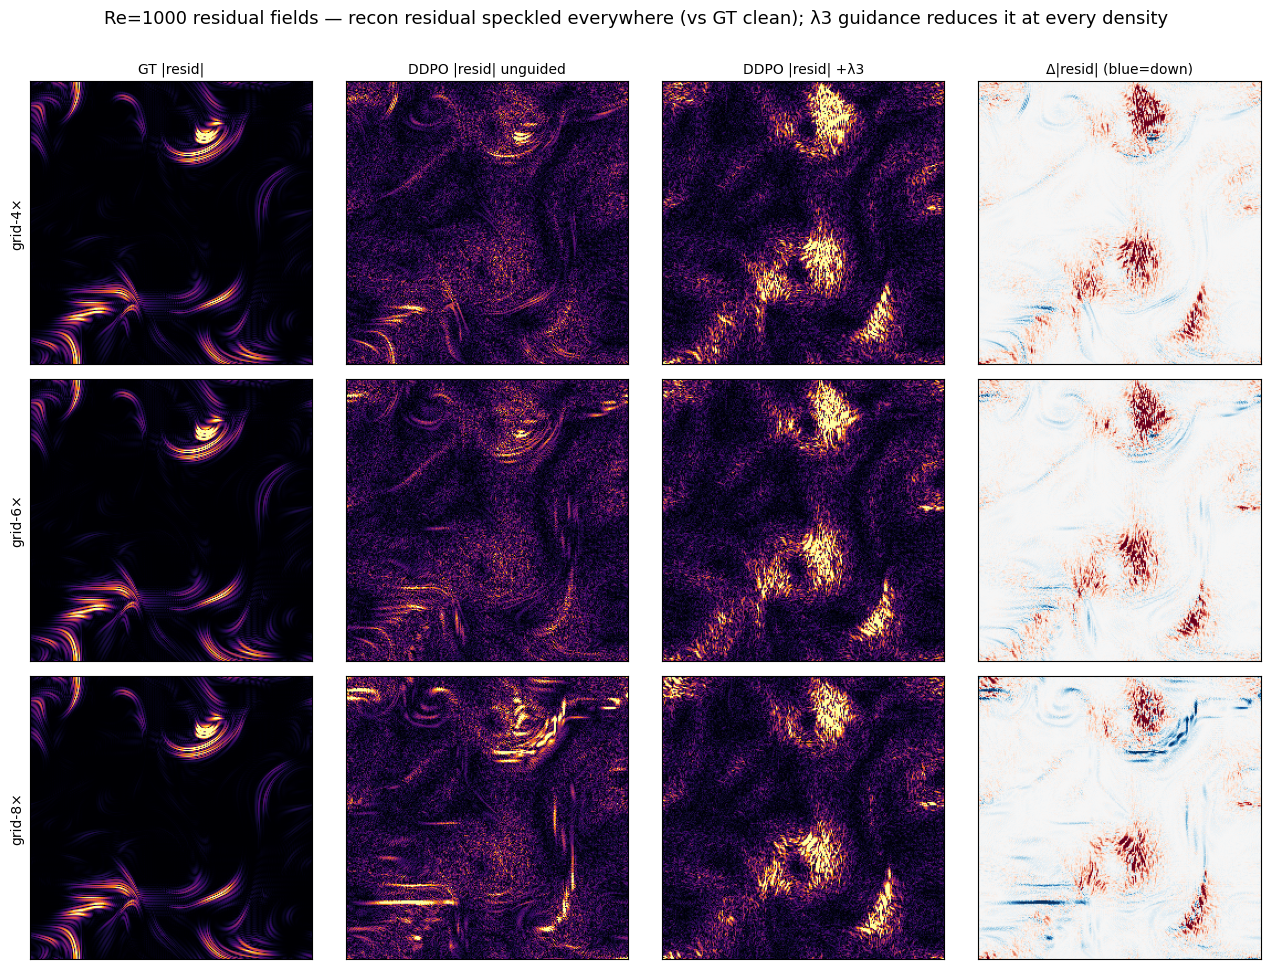

In [8]:
show_gf = [4, 6, 8]
Rg = np.abs(np.asarray(resid(jnp.asarray(xgt) * STD)))[0]
vR = float(np.percentile(Rg, 99) * 1.3)
fig, axes = plt.subplots(len(show_gf), 4, figsize=(13, 3.2 * len(show_gf)))
for r, gf in enumerate(show_gf):
    U, G = Z[f'{gf}_K1_DDPO_u'], Z[f'{gf}_K1_DDPO_g']
    Ru = np.abs(np.asarray(resid(jnp.asarray(U) * STD)))[0]
    Rgd = np.abs(np.asarray(resid(jnp.asarray(G) * STD)))[0]
    dR = Rgd - Ru; vD = float(np.percentile(np.abs(dR), 99)) + 1e-6
    panels = [('GT |resid|', Rg, 'inferno', 0, vR), ('DDPO |resid| unguided', Ru, 'inferno', 0, vR),
              ('DDPO |resid| +λ3', Rgd, 'inferno', 0, vR), ('Δ|resid| (blue=down)', dR, 'RdBu_r', -vD, vD)]
    for c, (nm, d, cm, vmn, vmx) in enumerate(panels):
        ax = axes[r, c]; ax.imshow(d, cmap=cm, vmin=vmn, vmax=vmx); ax.set_xticks([]); ax.set_yticks([])
        if r == 0: ax.set_title(nm, fontsize=10)
    axes[r, 0].set_ylabel(f'grid-{gf}×', fontsize=10)
fig.suptitle(f'Re={RE} residual fields — recon residual speckled everywhere (vs GT clean); '
             f'λ3 guidance reduces it at every density', y=1.005, fontsize=13)
plt.tight_layout(); plt.savefig(f'{LOGDIR}/grid_stress_residual.png', dpi=115, bbox_inches='tight'); plt.show()

## 5. Full metric table

In [9]:
print(f"{'re':>5}{'K':>3}{'grid':>5}{'pts':>6}{'model':>6}{'guide':>6}{'ret':>7}{'resid':>7}{'MSE':>8}{'place':>7}{'k*':>4}")
for re_val in (1000, 2000):
    for K in (1, 3):
        for gf in GRIDS:
            for m in ('base', 'DDPO'):
                for g in ('off', 'lam3'):
                    d = DATA.get((re_val, K, gf, m, g))
                    if d:
                        print(f"{re_val:>5}{K:>3}{gf:>5}{PTS[gf]:>6}{m:>6}{g:>6}"
                              f"{d['ret']:>7.3f}{d['resid']:>7.2f}{d['mse']:>8.4f}{d['place']:>7.3f}{d['kstar']:>4}")

   re  K grid   pts model guide    ret  resid     MSE  place  k*
 1000  1    4  4096  base   off  0.396   3.36  0.0158  0.821  31
 1000  1    4  4096  base  lam3  0.394   3.24  0.0159  0.825  31
 1000  1    4  4096  DDPO   off  0.607   3.44  0.0164  0.825  95
 1000  1    4  4096  DDPO  lam3  0.597   3.32  0.0164  0.822  95
 1000  1    5  2704  base   off  0.332   3.36  0.0147  0.583  25
 1000  1    5  2704  base  lam3  0.329   3.23  0.0146  0.586  25
 1000  1    5  2704  DDPO   off  0.476   3.42  0.0144  0.587  27
 1000  1    5  2704  DDPO  lam3  0.468   3.29  0.0144  0.585  26
 1000  1    6  1849  base   off  0.378   3.43  0.0330  0.404  23
 1000  1    6  1849  base  lam3  0.377   3.27  0.0330  0.394  22
 1000  1    6  1849  DDPO   off  0.485   3.47  0.0333  0.387  23
 1000  1    6  1849  DDPO  lam3  0.480   3.31  0.0333  0.385  23
 1000  1    7  1369  base   off  0.498   3.59  0.0439  0.339  24
 1000  1    7  1369  base  lam3  0.490   3.36  0.0438  0.337  24
 1000  1    7  1369  DDPO

## Findings

1. **K=3 multi-phase rescues placement at sparse inputs.** K=1 placement drops below the 0.6 "useful"
   line immediately past training density; K=3's renoise/denoise cascade re-imposes the sparse input each
   phase and holds base placement above 0.6 out to **grid-6× (1849 pts)** — ~1.5 grid-steps further.

2. **DDPO's sign flips by regime.** In-dist, DDPO+K=3 *overshoots* (retention 1.33 at grid-4×) and its extra
   energy places *worse* than base+K=3 → the best in-dist sparse config is **base+K=3**. OOD, the capacity-
   starved regime *needs* the added energy, so DDPO+K=3 places *better* than base (grid-6/7/8×).

3. **Guidance (λ=3) is the one universal win** — −4 to −10% residual at every grid factor, both K, both
   regimes (analytic physics, density-independent). It never touches placement or MSE, only residual.

4. **MSE collapse is fundamental.** Fidelity degrades 4–5× with sparsity (Re=1000: 0.016→0.079) and *nothing*
   — K, DDPO, or guidance — fixes it. It is pure information loss from sparser sampling.

**Bottom line.** Past grid-6× (~1850 pts, ~2.8% sampling) placement is gone and the output is hallucination
regardless of method. In the usable window: **base+K=3+λ3 in-dist**, **DDPO+K=3+λ3 OOD**.